In [1]:
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

In [33]:
DLATENT = '/Users/user/data/research/proton-deuteron/latentvectors/d_latent.npy'
PLATENT = '/Users/user/data/research/proton-deuteron/latentvectors/p_latent.npy'

HANDPICKED = '/Users/user/data/research/proton-deuteron/ssvd/handpicked_d.pkl'
CANDIDATES = '/Users/user/data/research/proton-deuteron/ssvd/deuteron_candidates_clean.pkl'
PROTONS = '/Users/user/data/research/proton-deuteron/ssvd/proton_candidates.pkl'

h = pd.read_pickle(HANDPICKED)
c = pd.read_pickle(CANDIDATES)

deuterons = pd.concat([h, c], ignore_index=True)

MOMENTUM_TOF = '/Users/user/data/research/proton-deuteron/momentum_tof.csv'
df = pd.read_csv(MOMENTUM_TOF)

deuterons = pd.merge(deuterons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

protons = pd.read_pickle(PROTONS)
protons = pd.merge(protons,
                     df,
                     on=['run', 'subrun', 'event'],
                     how='inner')

In [5]:
dlatent = np.load(DLATENT); print(dlatent.shape)
platent = np.load(PLATENT); print(platent.shape)

(5060, 8)
(7331, 8)


In [6]:
dY = np.ones((5060, 1))
pY = np.zeros((7331, 1))

In [7]:
X = np.vstack((dlatent, platent)); print(X.shape)
y = np.vstack((dY, pY)); print(y.shape)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

(12391, 8)
(12391, 1)


In [8]:
class Separater(nn.Module):
    def __init__(self, latent=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent, latent*2),
            nn.ReLU(),
            nn.Linear(latent*2, latent*4),
            nn.ReLU(),
            nn.Linear(latent*4, latent*8),
            nn.ReLU(),
            nn.Linear(latent*8, latent*2),
            nn.ReLU(),
            nn.Linear(latent*2, 2)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
model = Separater()
loss = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3)

In [28]:
for epoch in range(10):
    for xb, yb in loader:
        yb = yb.squeeze(1).long()
        optimiser.zero_grad()
        logits = model(xb)
        l = loss(logits, yb)
        l.backward()
        optimiser.step()
    print(f'Epoch {epoch}, Loss: {l.item():.4f}')

Epoch 0, Loss: 0.4396
Epoch 1, Loss: 0.4410
Epoch 2, Loss: 0.4665
Epoch 3, Loss: 0.5684
Epoch 4, Loss: 0.5141
Epoch 5, Loss: 0.4853
Epoch 6, Loss: 0.4387
Epoch 7, Loss: 0.4628
Epoch 8, Loss: 0.4988
Epoch 9, Loss: 0.5305


In [29]:
with torch.no_grad():
    test_x = torch.tensor(dlatent)
    logits = model(test_x)
    probs = F.softmax(logits, dim=1)

In [30]:
probs

tensor([[0.1293, 0.8707],
        [0.3729, 0.6271],
        [0.0018, 0.9982],
        ...,
        [0.5873, 0.4127],
        [0.5243, 0.4757],
        [0.6696, 0.3304]])

In [31]:
probs.shape

torch.Size([5060, 2])

(array([ 38., 125., 190., 206., 271., 305., 293., 279., 315., 234., 223.,
        227., 215., 211., 175., 173., 149., 178., 287., 966.]),
 array([0.02462216, 0.07338978, 0.12215739, 0.17092501, 0.21969263,
        0.26846024, 0.31722784, 0.36599547, 0.41476309, 0.46353072,
        0.51229835, 0.56106597, 0.60983354, 0.65860116, 0.70736879,
        0.75613642, 0.80490404, 0.85367167, 0.9024393 , 0.95120692,
        0.99997449]),
 <BarContainer object of 20 artists>)

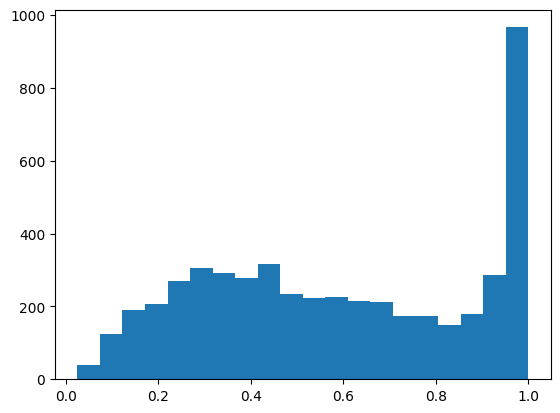

In [32]:
plt.hist(probs[:, 1], bins=20)

In [25]:
deuterons['prob'] = probs[:, 1].numpy()

In [26]:
d = deuterons[deuterons['prob'] >= 0.95]; print(len(d))
p = deuterons[deuterons['prob'] < 0.95]

860


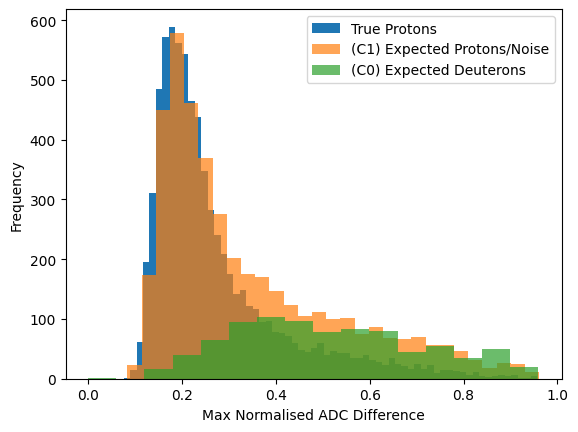

In [27]:
plt.hist(protons['maxdiff'], bins='auto', alpha=1, label='True Protons')
plt.hist(p['maxdiff'], bins='auto', alpha=0.7, label='(C1) Expected Protons/Noise')
plt.hist(d['maxdiff'], bins='auto', alpha=0.7, label='(C0) Expected Deuterons')
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

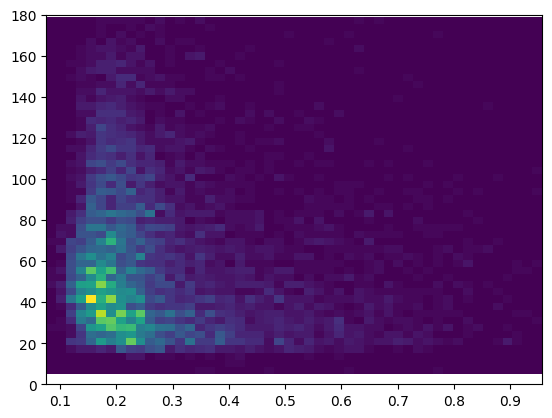

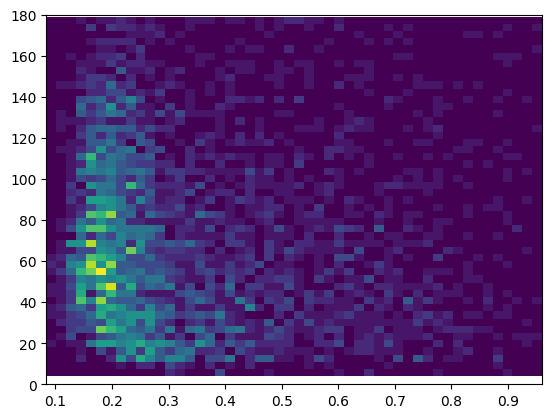

/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_33673/2766581428.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_33673/2766581428.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


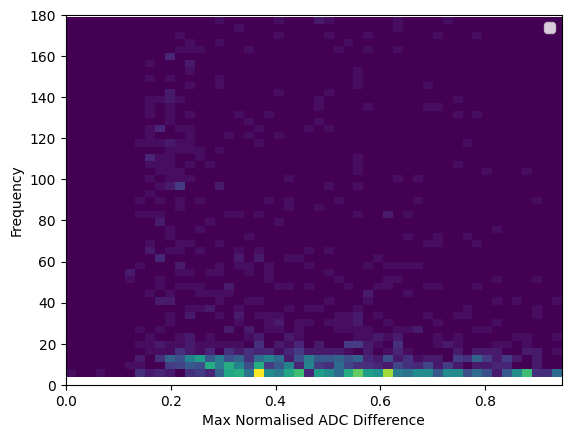

In [258]:
plt.hist2d(protons['maxdiff'].values, protons['height'].values, bins=50, alpha=1, label='True Protons')
plt.ylim(0, 180)
plt.show()
plt.hist2d(p['maxdiff'], p['height'], bins=50, alpha=1, label='(C1) Expected Protons/Noise')
plt.ylim(0, 180)
plt.show()
plt.hist2d(d['maxdiff'], d['height'], bins=50, alpha=1, label='(C0) Expected Deuterons')
plt.ylim(0, 180)
plt.xlabel('Max Normalised ADC Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# TODO: HOW TO NOT OVERFIT?
# TODO: HOW TO EVALUATE THE CLUSTERING? 
# TODO: HOW MANY DEUTERONS DO WE EXPECT?
# TODO: SPLIT
# TODO: ANOMALY DETECTION - SCIKIT LEARN
# TODO: IMAGES